# Week 11 - 앙상블

**빅데이터 응용 실습 | Bagging, Boosting, XGBoost, LightGBM**
---

## 앙상블 학습(Ensemble Learning)의 핵심 아이디어는 단순하다.
**- 여러개의 모델을 결합하여, 모델이 낼 수 없는 하나의 더 강력하고 안정적인 모델을 만드는 것**
- 예측성능 향상
- 모델의 안정성 확보
- 과적합 완화

## 앙상블이 필요한 이유(Bias, Variance)
- 편향: 과소적합
- 분산: 과적합
**개별 모델의 약점을 평균화하여 더 안정적이고 일반화 성능이 뛰어난 모델을 탄생시킨다.**

## 앙상블을 구현하는 두 가지 방법
- Bagging(Bootstrap Aggregating): 독립과 다수결
    - 학습 방식: 병렬적으로 독립적인 학습 후 결과 종합
    - 주요 목적: Variance 감소(안정성 극대화)
    - 대표 모델: Random Forest
- Boosting: 집중과 약점 보완
    - 학습 방식: 순차적으로 이전 모델의 실수를 보완하며 학습
    - 주요 목적: Bias 감소(정확도 극대화)
    - 대표 모델: XGBoost, LightGBM

- Bagging
    - 원본 데이터에서 중복을 허용하여 여러 개의 조금씩 다른 데이터셋을 무작위로 생성
    - 병렬 학습: 각각의 데이터셋으로 동일한 구조의 모델들을 동시에 학습시킴
    - 분류 문제는 다수결, 회귀 문제는 평균을 내어 최종 예측값을 산출합니다.
- RandomForest(Bagging)
    - 모든 변수를 보지 않고, 노드를 분할할 때 무작위로 일부 변수만 선택하여 트리를 만듭니다.
    - 효과: 트리들 간의 상관관계가 크게 줄어들어, 단일 결정트리보다 압도적인 안정성과 일반화 성능을 가집니다.
    - 하이퍼파라미터 튜닝 부담이 적으며, 기본 설정만으로도 매우 강력한 베이스라인 성능을 냅니다.

- Boosting: 오답노트를 통한 끊임 없는 성장
    - 이전 모델이 예측에 실패한 데이터(오류)를 식별하고 가중치를 부여합니다.
    - 다음 모델은 그 틀린 데이터를 더 잘 맞추도록 순차적으로 학습합니다.
    - 모델들이 독립적이지 않고, 편향을 줄이는데 효과적이나, 과적합 위험이 있고 학습시간이 상대적으로 길다. 하이퍼파라미터 설정이 매우 중요하다.

## Gradient Boosting -> XGBoost로의 진화

- Gradient Boosting의 핵심
    - 이전 모델의 잔차를 다음 모델이 예측하도록 학습.
    - 손실 함수의 기울기를 따라 점진적으로 성능을 향상시킵니다.

- XGBoost (eXtreme Gradient Boosting)의 등장
    - 기존 모델의 한계를 하드웨어 및 알고리즘 최적화로 극복
    - 연산 최적화 & 병렬 처리: 하드웨어 자원을 극한으로 활용하여 속도 혁신
    - 정규화(Regularization): 과적합 방지 항 추가
    - 결측치 자동 처리

## LightGBM: 대용량 데이터를 위한 초고속 엔진

XGBoost 보다 더 빠른 메모리 효율성을 목표로 설계된 마이크로소프트의 걸작
- 기존 방식(Level Wise)
    - 트리의 균형을 맞추며 층별로 성장, 안정적이지만 불필요한 연산이 발생함
- Leaf-wise(LightGBM)
    - 최대 손실 값을 가지는 리프 노드만 계속 분할하여 비대칭적으로 성장. 오차를 가장 빠르게 줄임.(+ 히스토그램 기반 학습)
    - 장점: 압도적인 학습 속도, 대용량 데이터 처리에 최적화, 뛰어난 메모리 효율
    - 단점: 데이터 크기가 작을 경우(일반적으로 1만건 이하) 과적합 위험이 높음, 민감한 파라미터

| | Bagging | Boosting |
| :--- | :--- | :--- |
| **주요 목적** | **분산**(Variance) 감소 (안정성 강화) | **편향**(Bias) 감소 (정확도 향상) |
| **학습 방식** | **병렬 학습** (상호 독립적) | **순차 학습** (상호 의존적) |
| **강점과 약점** | **안정적**이고 튜닝 부담이 적으나 다소 무거움 | **강력한 성능**을 내지만 과적합 위험과 튜닝 난이도가 높음 |
| **대표 모델** | **Random Forest** | **XGBoost**, LightGBM |


| 구분 | XGBoost | LightGBM |
| :--- | :--- | :--- |
| **핵심 특징** | **강력하고 묵직한 정통파** | **압도적인 속도와 효율** |
| **트리 성장 방식** | Level-wise (균형 트리) | Leaf-wise (비대칭 트리) |
| **학습 속도** | 상대적으로 느림 | 매우 빠름 (히스토그램 기반 최적화) |
| **메모리 사용량** | 높음 | 낮음 (효율적) |
| **추천 상황** | 데이터 크기가 적당하고, 과적합 제어와 최고 수준의 정확도가 최우선일 때. | 데이터가 매우 크고 학습 시간이 중요할 때. 실무 환경의 대규모 데이터 처리. |


| 상황 및 데이터 조건 | 모델 선택 (추천) |
| :--- | :--- |
| 빠르게 안정적인 베이스라인 성능이 필요한가? | **Random Forest** <br>(튜닝 부담 없음) |
| 최고의 성능(대회 1위, 예측 정확도 최우선)이 목표인가? | **XGBoost / LightGBM** <br>(정교한 튜닝 병행) |
| 데이터가 매우 크고(수만 건 이상) 학습 시간이 제한적인가? | **LightGBM** <br>(메모리 효율 최고) |
| 모델의 예측 결과에 대한 해석 가능성(설명력)이 중요한가? | **얕은 트리 + Feature Importance / SHAP 분석 병행** |


---

# 실습 목표
- 앙상블 학습과 비교실험: DecisionTree / RandomForest / Gradient Boosting / XGBoost / LightGBM
- 실습목표
    - 단일 트리와 앙상블 모델의 성능 차이를 직접 확인한다.
    - Bagging(Random Forest)과 Boosting(Gradient Boosting, XGBoost, LightGBM)의 차이를 체감한다.
    - 동일한 데이터에서 모델별 성능과 해석을 비교한다.
    - 성능 숫자만 제시하는 것이 아니라, 왜 그런 차이가 발생하는지 문장으로 설명할 수 있다.

In [6]:
# 1. 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

plt.rcParams["figure.figsize"] = (6, 4)

In [9]:
data = load_breast_cancer()

x = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

display(x.head())
print(x.shape)
print(y.shape)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


(569, 30)
(569,)


target
1    357
0    212
Name: count, dtype: int64

target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


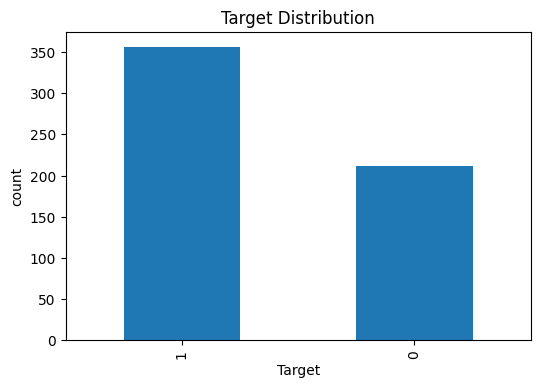

In [13]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True))

y.value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Target')
plt.ylabel('count')
plt.show()

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

print(x_test.shape)
print(x_train.shape)
print(y_test.shape)
print(y_train.shape)

(171, 30)
(398, 30)
(171,)
(398,)


In [19]:
start = time.time()

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
pred_dt=dt.predict(x_test)

time_dt = time.time() - start

acc_dt = accuracy_score(y_test, pred_dt)
recall_dt = recall_score(y_test, pred_dt)
precision_dt = precision_score(y_test, pred_dt)
f1_dt = f1_score(y_test, pred_dt)

print(round(acc_dt, 4))
print(round(recall_dt, 4))
print(round(precision_dt, 4))
print(round(f1_dt, 4))
print()
print(classification_report(y_test, pred_dt))

0.9181
0.9346
0.9346
0.9346

              precision    recall  f1-score   support

           0       0.89      0.89      0.89        64
           1       0.93      0.93      0.93       107

    accuracy                           0.92       171
   macro avg       0.91      0.91      0.91       171
weighted avg       0.92      0.92      0.92       171



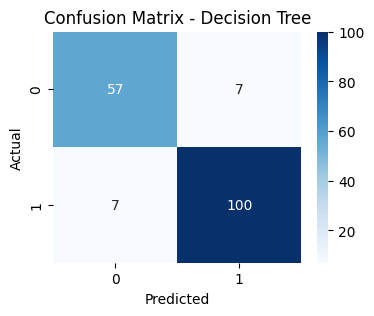

In [20]:
# 6. 혼동행렬 시각화 - Decision Tree
cm_dt = confusion_matrix(y_test, pred_dt)

plt.figure(figsize=(4, 3))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [21]:
# 7. Random Forest 학습 및 평가
start = time.time()

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
pred_rf = rf.predict(x_test)

time_rf = time.time() - start

acc_rf = accuracy_score(y_test, pred_rf)
recall_rf = recall_score(y_test, pred_rf)
precision_rf = precision_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf)

print("Accuracy :", round(acc_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("Precision:", round(precision_rf, 4))
print("F1-score :", round(f1_rf, 4))
print("Train+Predict Time:", round(time_rf, 4), "sec")
print()
print(classification_report(y_test, pred_rf))


Accuracy : 0.9357
Recall   : 0.9533
Precision: 0.9444
F1-score : 0.9488
Train+Predict Time: 0.0684 sec

              precision    recall  f1-score   support

           0       0.92      0.91      0.91        64
           1       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



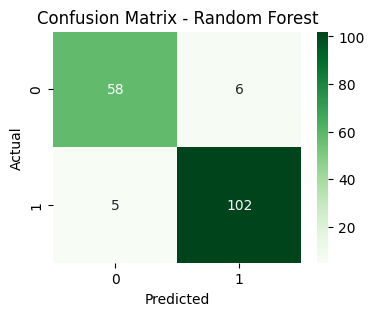

In [22]:
# 8. 혼동행렬 시각화 - Random Forest
cm_rf = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(4, 3))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [23]:
# 9. Gradient Boosting 학습 및 평가
start = time.time()

gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_train, y_train)
pred_gb = gb.predict(x_test)

time_gb = time.time() - start

acc_gb = accuracy_score(y_test, pred_gb)
recall_gb = recall_score(y_test, pred_gb)
precision_gb = precision_score(y_test, pred_gb)
f1_gb = f1_score(y_test, pred_gb)

print("Accuracy :", round(acc_gb, 4))
print("Recall   :", round(recall_gb, 4))
print("Precision:", round(precision_gb, 4))
print("F1-score :", round(f1_gb, 4))
print("Train+Predict Time:", round(time_gb, 4), "sec")
print()
print(classification_report(y_test, pred_gb))


Accuracy : 0.9474
Recall   : 0.972
Precision: 0.9455
F1-score : 0.9585
Train+Predict Time: 0.1743 sec

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        64
           1       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



---

In [25]:
# 10. XGBoost 설치 확인 및 실행
try:
    from xgboost import XGBClassifier
    
    start = time.time()
    
    xgb = XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    )
    xgb.fit(x_train, y_train)
    pred_xgb = xgb.predict(x_test)
    
    time_xgb = time.time() - start
    
    acc_xgb = accuracy_score(y_test, pred_xgb)
    recall_xgb = recall_score(y_test, pred_xgb)
    precision_xgb = precision_score(y_test, pred_xgb)
    f1_xgb = f1_score(y_test, pred_xgb)
    
    print("Accuracy :", round(acc_xgb, 4))
    print("Recall   :", round(recall_xgb, 4))
    print("Precision:", round(precision_xgb, 4))
    print("F1-score :", round(f1_xgb, 4))
    print("Train+Predict Time:", round(time_xgb, 4), "sec")
    print()
    print(classification_report(y_test, pred_xgb))

except Exception as e:
    acc_xgb = np.nan
    recall_xgb = np.nan
    precision_xgb = np.nan
    f1_xgb = np.nan
    time_xgb = np.nan
    print("XGBoost 실행 불가:", e)
    print("설치 예시: pip install xgboost")


Accuracy : 0.9649
Recall   : 0.9907
Precision: 0.955
F1-score : 0.9725
Train+Predict Time: 0.1049 sec

              precision    recall  f1-score   support

           0       0.98      0.92      0.95        64
           1       0.95      0.99      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.97      0.96      0.96       171



In [27]:
# 11. LightGBM 설치 확인 및 실행
try:
    from lightgbm import LGBMClassifier
    
    start = time.time()
    
    lgbm = LGBMClassifier(random_state=42, verbose=-1)
    lgbm.fit(x_train, y_train)
    pred_lgbm = lgbm.predict(x_test)
    
    time_lgbm = time.time() - start
    
    acc_lgbm = accuracy_score(y_test, pred_lgbm)
    recall_lgbm = recall_score(y_test, pred_lgbm)
    precision_lgbm = precision_score(y_test, pred_lgbm)
    f1_lgbm = f1_score(y_test, pred_lgbm)
    
    print("Accuracy :", round(acc_lgbm, 4))
    print("Recall   :", round(recall_lgbm, 4))
    print("Precision:", round(precision_lgbm, 4))
    print("F1-score :", round(f1_lgbm, 4))
    print("Train+Predict Time:", round(time_lgbm, 4), "sec")
    print()
    print(classification_report(y_test, pred_lgbm))

except Exception as e:
    acc_lgbm = np.nan
    recall_lgbm = np.nan
    precision_lgbm = np.nan
    f1_lgbm = np.nan
    time_lgbm = np.nan
    print("LightGBM 실행 불가:", e)
    print("설치 예시: pip install lightgbm")


Accuracy : 0.9591
Recall   : 0.9813
Precision: 0.9545
F1-score : 0.9677
Train+Predict Time: 0.3511 sec

              precision    recall  f1-score   support

           0       0.97      0.92      0.94        64
           1       0.95      0.98      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [28]:
# 12. 모델 비교 표
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost", "LightGBM"],
    "Accuracy": [acc_dt, acc_rf, acc_gb, acc_xgb, acc_lgbm],
    "Recall": [recall_dt, recall_rf, recall_gb, recall_xgb, recall_lgbm],
    "Precision": [precision_dt, precision_rf, precision_gb, precision_xgb, precision_lgbm],
    "F1-score": [f1_dt, f1_rf, f1_gb, f1_xgb, f1_lgbm],
    "Time_sec": [time_dt, time_rf, time_gb, time_xgb, time_lgbm]
})

results.sort_values("Accuracy", ascending=False)


,Model,Accuracy,Recall,Precision,F1-score,Time_sec
3,XGBoost,0.964912,0.990654,0.954955,0.972477,0.104856
4,LightGBM,0.959064,0.981308,0.954545,0.967742,0.351112
2,Gradient Boosting,0.947368,0.971963,0.945455,0.958525,0.174315
1,Random Forest,0.935673,0.953271,0.944444,0.948837,0.068351
0,Decision Tree,0.918129,0.934579,0.934579,0.934579,0.005672


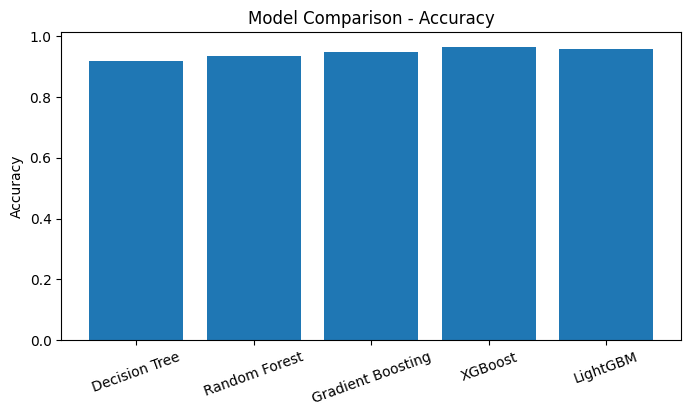

In [29]:
# 13. Accuracy 비교 시각화
plt.figure(figsize=(8, 4))
plt.bar(results["Model"], results["Accuracy"])
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Comparison - Accuracy")
plt.show()

worst concave points    0.158955
worst area              0.146962
worst perimeter         0.085793
worst radius            0.078952
mean radius             0.077714
mean perimeter          0.074234
mean concave points     0.065869
mean concavity          0.054281
mean area               0.041657
worst concavity         0.031362
dtype: float64

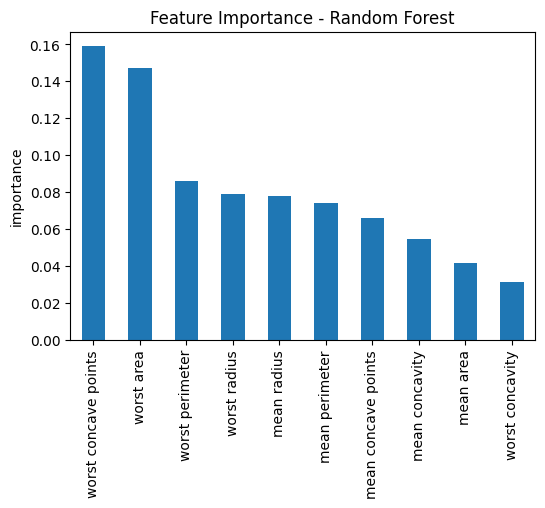

In [30]:
# 15. Random Forest 변수 중요도
rf_importances = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
display(rf_importances.head(10))

rf_importances.head(10).plot(kind="bar")
plt.title("Feature Importance - Random Forest")
plt.ylabel("importance")
plt.show()


In [31]:
# 17. n_estimators 변화 실험
rf_rows = []

for n in [10, 50, 100, 200]:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    
    rf_rows.append({
        "n_estimators": n,
        "Accuracy": accuracy_score(y_test, pred),
        "F1-score": f1_score(y_test, pred)
    })
    
rf_summary = pd.DataFrame(rf_rows)
rf_summary


,n_estimators,Accuracy,F1-score
0,10,0.929825,0.943396
1,50,0.923977,0.938967
2,100,0.935673,0.948837
3,200,0.941520,0.953704


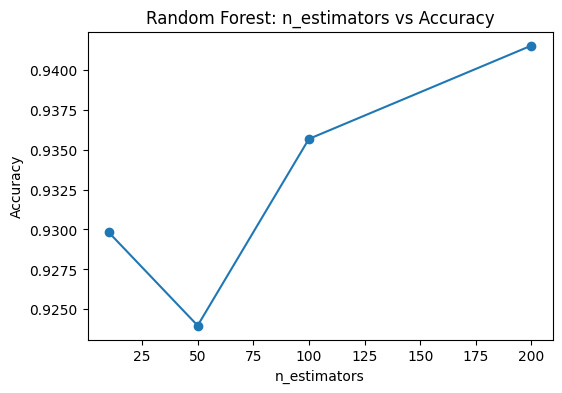

In [32]:
# 18. n_estimators 변화 시각화
plt.plot(rf_summary["n_estimators"], rf_summary["Accuracy"], marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Random Forest: n_estimators vs Accuracy")
plt.show()


In [33]:
# 19. learning_rate 변화 실험
gb_rows = []

for lr in [0.01, 0.1, 0.3]:
    model = GradientBoostingClassifier(learning_rate=lr, random_state=42)
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    
    gb_rows.append({
        "learning_rate": lr,
        "Accuracy": accuracy_score(y_test, pred),
        "F1-score": f1_score(y_test, pred)
    })
    
gb_summary = pd.DataFrame(gb_rows)
gb_summary


,learning_rate,Accuracy,F1-score
0,0.01,0.935673,0.949309
1,0.10,0.947368,0.958525
2,0.30,0.947368,0.958525


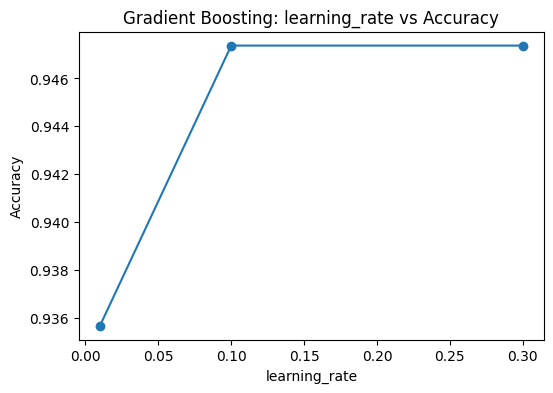

In [34]:
# 20. learning_rate 변화 시각화
plt.plot(gb_summary["learning_rate"], gb_summary["Accuracy"], marker="o")
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting: learning_rate vs Accuracy")
plt.show()
